In [117]:
import numpy as np
import math
import numpy as np
from scipy.optimize import minimize

from scipy.stats import chi2, norm

import matplotlib.pyplot as plt

In [107]:
data = []
with open("normal.data.txt") as f:
    data = f.read().replace("\n", " ").split()
    data = [float(i) for i in data]
data = np.array(data)
n = len(data)
print(data.shape)

(200,)


In [108]:
def likelihood(mu: float, sigma: float):
    p = 0
    for x in data:
        p += ((x - mu) ** 2) / (2 * sigma**2)
        p += math.log(sigma)
    # return -p - len(data)* math.log(sigma)
    return -p

In [109]:
def neg_likelihood(theta):
    mu, sigma = theta
    return -1 * likelihood(mu, sigma)


init_guess = [0, 1]  # [mu, sigma2]
result = minimize(neg_likelihood, init_guess, bounds=[(None, None), (1e-10, None)])
numeric_mu, numeric_std = result.x
print(numeric_mu, numeric_std)
print(likelihood(numeric_mu, numeric_std))

100.48050398080368 14.707763577982128
-637.67517188192


In [110]:
theory_mu = np.mean(data)
theory_sigma = np.sqrt((np.sum([(x - theory_mu) ** 2 for x in data])) / n)
print(theory_mu, theory_sigma)
print(likelihood(theory_mu, theory_sigma))

100.48049999999999 14.707769026946268
-637.6751718818854


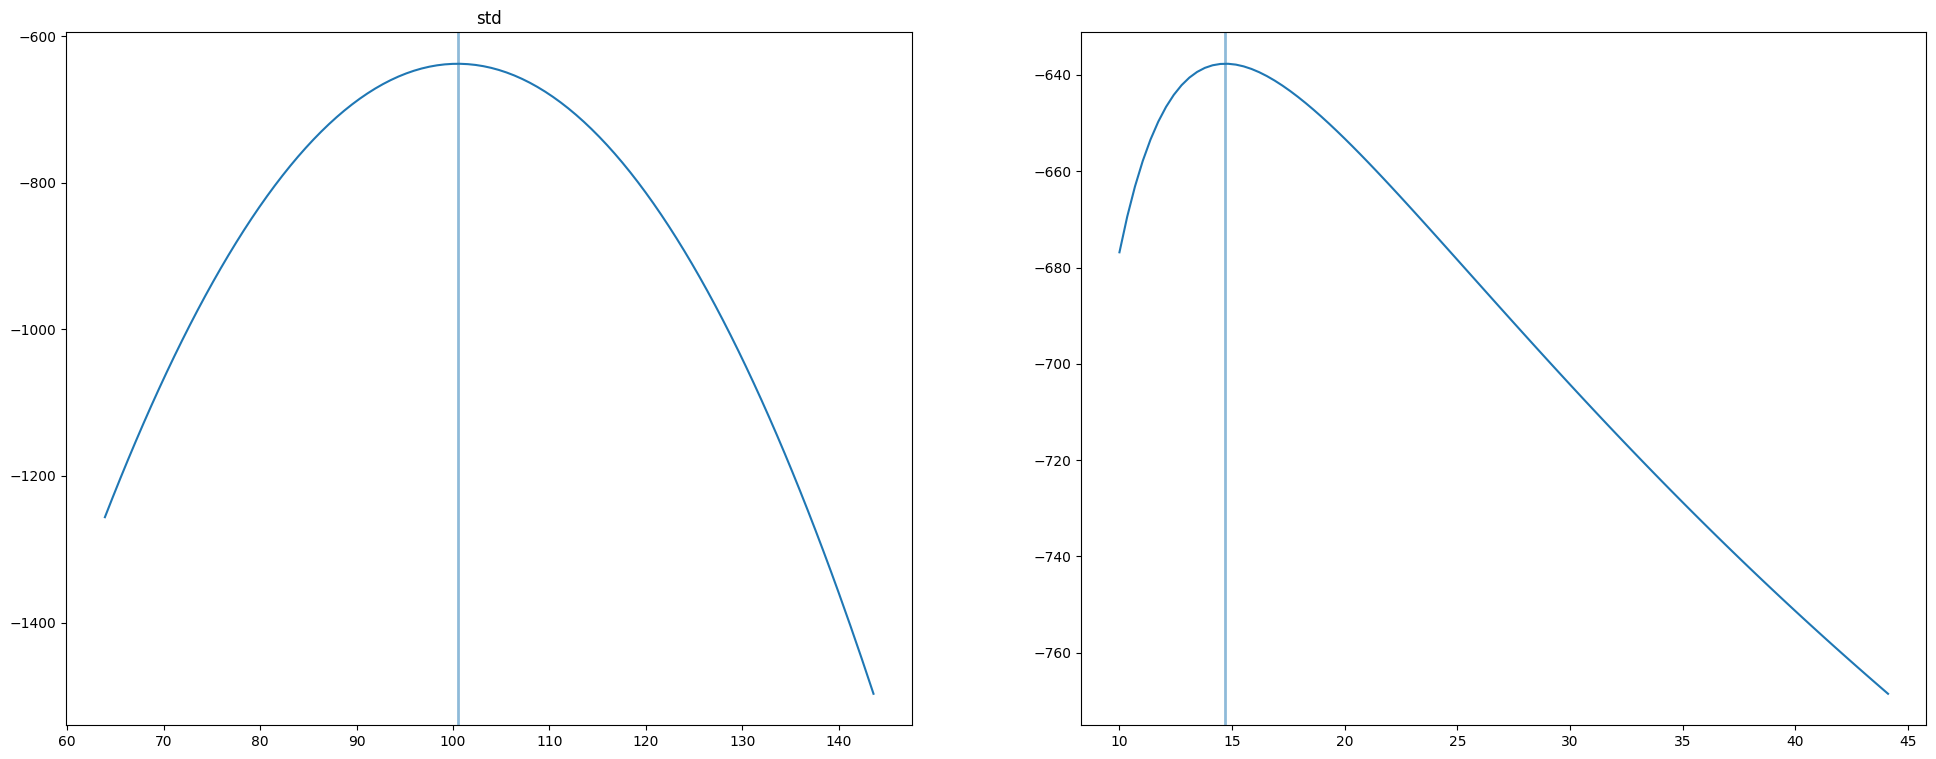

In [111]:
plt.figure(figsize=(24, 9))

mus = np.linspace(min(data), max(data), len(data))
plt.subplot(1, 2, 1)
plt.title("mean")
plt.plot(mus, [likelihood(i, theory_sigma) for i in mus])
plt.axvline(theory_mu, alpha=0.5, lw=2)

plt.title("std")
sigmas = np.linspace(10, 3 * theory_sigma, 100)
plt.subplot(1, 2, 2)
plt.plot(sigmas, [likelihood(theory_mu, i) for i in sigmas])
# plt.log
plt.axvline(theory_sigma, alpha=0.5, lw=2)

In [112]:
# 3
print(numeric_std**2 / n)
print(2 * numeric_std**4 / n)
print("##################")
print(theory_sigma**2 / n)
print(2 * theory_sigma**4 / n)

1.0815915473290882
467.93611010149255
##################
1.0815923487499999
467.93680354981655


In [116]:
# CI

s2 = np.var(data, ddof=1)
alpha = 0.05  # 95% CI

df = n - 1
chi2_lower = chi2.ppf(1 - alpha / 2, df)  # X_{0.975, 14}
chi2_upper = chi2.ppf(alpha / 2, df)  # X_{0.025, 14}

ci_exact = [((n - 1) * s2 / chi2_lower) ** 0.5, ((n - 1) * s2 / chi2_upper) ** 0.5]


print(f"[{ci_exact[0]:.4f}, {ci_exact[1]:.4f}]")

[13.4274, 16.3507]


In [120]:
def z_test(mu0):
    z = (theory_mu - mu0) / (theory_sigma / np.sqrt(n))
    p = 2 * (1 - norm.cdf(abs(z)))
    return p


print(z_test(103))

0.0154096835916544
